# HyperRAG V2 — Notebook 3: HtmlRAG

**Goal:** Understand what HtmlRAG does differently from Simple RAG, and compare them on 20 questions.

**The core idea:**  
Simple RAG strips all HTML and passes plain text to the LLM (or metric).  
HtmlRAG passes **structured HTML** — keeping `<h1>`, `<h2>`, `<p>`, `<li>`, `<table>` tags — so an LLM can use the document structure (headings, lists, tables) as additional signal.

**Same retrieval step, different context format:**
```
Simple RAG:  query → FAISS → pages → plain text context
HtmlRAG:     query → FAISS → pages → cleaned HTML context
```

**Prerequisite:** Run notebooks 01 and 02 first.


In [1]:
import json
from pathlib import Path
from collections import Counter

import faiss
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from bs4 import BeautifulSoup
from sentence_transformers import SentenceTransformer

# ── Paths ─────────────────────────────────────────────────────────────────────
if Path('utils.py').exists():
    BASE_DIR = Path('.')
elif Path('v2/utils.py').exists():
    BASE_DIR = Path('v2')
else:
    raise FileNotFoundError('Run from v2/ or from HyperRAG-M2/')

DATA_DIR = BASE_DIR / 'data'

with open(DATA_DIR / 'corpus_001.json')    as f: corpus    = json.load(f)
with open(DATA_DIR / 'questions_001.json') as f: questions = json.load(f)

print(f'Corpus    : {len(corpus)} pages')
print(f'Questions : {len(questions)} questions')


W0427 23:17:18.101000 48820 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Corpus    : 9999 pages
Questions : 5329 questions


---
## Step 1 — Look at Raw Wikipedia HTML

Before cleaning, let's see what Wikipedia HTML looks like. It's messy — full of scripts, styles, infoboxes, and navigation elements that are useless for QA.


In [2]:
# Show raw HTML of the first corpus page
page = corpus[0]
print(f'Page: {page["title"]}')
print(f'HTML length: {len(page["html"])} chars')
print()
print('First 600 chars of raw HTML:')
print('-' * 60)
print(page['html'][:600])
print('...')


Page: The Oberoi Group
HTML length: 82650 chars

First 600 chars of raw HTML:
------------------------------------------------------------
<div class="mw-content-ltr mw-parser-output" lang="en" dir="ltr"><div class="shortdescription nomobile noexcerpt noprint searchaux" style="display:none">Indian luxury hotel group</div>
<p class="mw-empty-elt">

</p>
<style data-mw-deduplicate="TemplateStyles:r1316064257">.mw-parser-output .infobox-subbox{padding:0;border:none;margin:-3px;width:auto;min-width:100%;font-size:100%;clear:none;float:none;background-color:transparent;color:inherit}.mw-parser-output .infobox-3cols-child{margin:-3px}.mw-parser-output .infobox .navbar{font-size:100%}@media screen{html.skin-theme-clientpref-night .mw-pa
...


In [3]:
# Compare with plain text of the same page
print(f'Page: {page["title"]}')
print(f'Text length: {len(page["text"])} chars')
print()
print('First 600 chars of plain text:')
print('-' * 60)
print(page['text'][:600])


Page: The Oberoi Group
Text length: 3360 chars

First 600 chars of plain text:
------------------------------------------------------------
Indian luxury hotel group The Oberoi Group is a luxury hotel group with its head office in New Delhi , India . Founded in 1934, the company owns and operates 32 luxury hotels and two river cruise ships in 7 countries, primarily under its Oberoi Hotels & Resorts and Trident brands. The group also operates The Oberoi Centre of Learning and Development, which is regarded as one of Asia 's top institutions for hospitality education. History [ edit ] The foundations of The Oberoi Group date back to 1934 when Rai Bahadur Mohan Singh Oberoi , the founder of the group, bought two properties: the Maide


---
## Step 2 — HTML Cleaning Function

HtmlRAG does not pass raw HTML to the LLM. It **cleans** the HTML first:
- Remove: `<script>`, `<style>`, `<nav>`, `<sup>` (footnotes)
- Keep: `<h1>`, `<h2>`, `<p>`, `<li>`, `<table>` (these carry meaning)

The result is a much smaller, structured HTML string.


In [4]:
def clean_html(html: str) -> str:
    """
    Remove noisy elements from Wikipedia HTML.
    Keeps structural tags: h1, h2, p, li, table.
    Removes: script, style, nav, sup (footnote numbers).
    """
    soup = BeautifulSoup(html, 'html.parser')
    for tag in soup.find_all(['script', 'style', 'nav', 'sup']):
        tag.decompose()   # remove tag + all its children
    return str(soup)


print('clean_html() defined.')


clean_html() defined.


In [5]:
# ── Test clean_html on the first corpus page ──────────────────────────────────
raw_html    = page['html']
cleaned     = clean_html(raw_html)

print(f'Raw HTML    : {len(raw_html):,} chars')
print(f'Cleaned HTML: {len(cleaned):,} chars')
print(f'Size reduction: {(1 - len(cleaned)/len(raw_html))*100:.1f}%')
print()
print('First 600 chars of cleaned HTML:')
print('-' * 60)
print(cleaned[:600])


Raw HTML    : 82,650 chars
Cleaned HTML: 67,146 chars
Size reduction: 18.8%

First 600 chars of cleaned HTML:
------------------------------------------------------------
<div class="mw-content-ltr mw-parser-output" dir="ltr" lang="en"><div class="shortdescription nomobile noexcerpt noprint searchaux" style="display:none">Indian luxury hotel group</div>
<p class="mw-empty-elt">
</p>
<table class="infobox ib-company vcard"><caption class="infobox-title fn org" style="font-size: 125%;">The Oberoi Group</caption><tbody><tr><td class="infobox-image ib-company-logo logo" colspan="2"><span class="mw-default-size" typeof="mw:File/Frameless"><a class="mw-file-description" href="/wiki/File:The_Oberoi_Group.png"><img class="mw-file-element mw-file-upright" data-file-heig


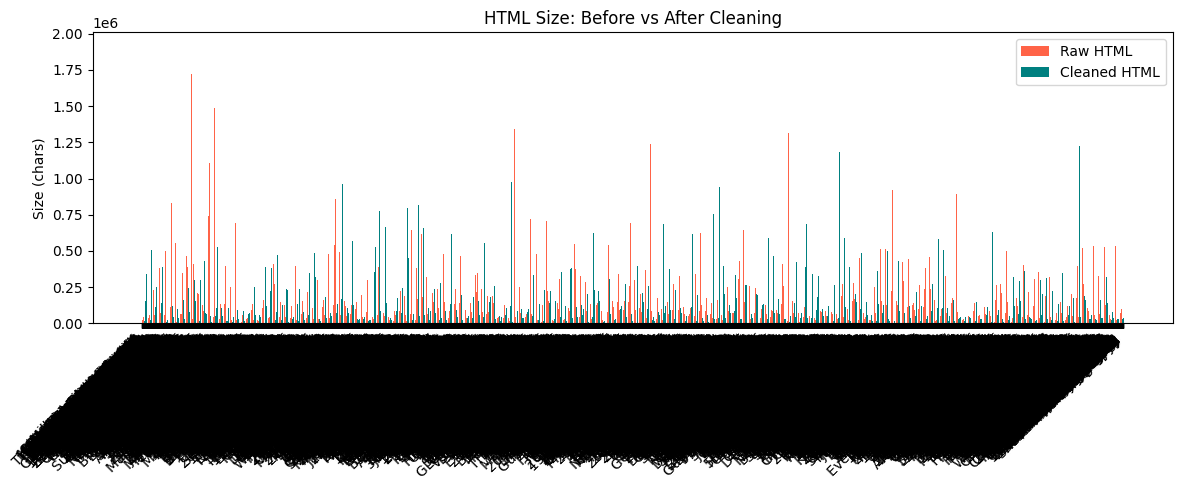

In [6]:
# Visualize size reduction for all corpus pages
raw_sizes     = [len(p['html']) for p in corpus]
cleaned_sizes = [len(clean_html(p['html'])) for p in corpus]
titles_short  = [p['title'][:22] for p in corpus]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(corpus))
ax.bar([i - 0.2 for i in x], raw_sizes,     0.4, label='Raw HTML',     color='tomato')
ax.bar([i + 0.2 for i in x], cleaned_sizes, 0.4, label='Cleaned HTML', color='teal')
ax.set_xticks(list(x))
ax.set_xticklabels(titles_short, rotation=45, ha='right')
ax.set_ylabel('Size (chars)')
ax.set_title('HTML Size: Before vs After Cleaning')
ax.legend()
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'htmlrag_cleaning.png'), dpi=100, bbox_inches='tight')
plt.show()


---
## Step 3 — Reuse the Same Embedding & Retrieval Functions

HtmlRAG uses **exactly the same retrieval** as Simple RAG. The difference is only in the context it returns — HTML instead of plain text.

We copy the embed / build_index / retrieve functions here so this notebook is self-contained.


In [7]:
MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
_model = None

def get_model():
    global _model
    if _model is None:
        print(f'Loading {MODEL_NAME} ...')
        _model = SentenceTransformer(MODEL_NAME)
        print('Model ready.')
    return _model

def embed_texts(texts):
    model = get_model()
    vecs  = model.encode(texts, show_progress_bar=len(texts) > 20, convert_to_numpy=True)
    vecs  = vecs.astype('float32')
    faiss.normalize_L2(vecs)
    return vecs

def build_index(corpus):
    print(f'Building index for {len(corpus)} pages ...')
    vecs = embed_texts([p['text'] for p in corpus])
    idx  = faiss.IndexFlatIP(vecs.shape[1])
    idx.add(vecs)
    print(f'Index ready: {idx.ntotal} vectors')
    return idx

def retrieve(query, index, corpus, k=5):
    q_vec = embed_texts([query])
    scores, indices = index.search(q_vec, k)
    results = []
    for i, s in zip(indices[0], scores[0]):
        if 0 <= i < len(corpus):
            p = dict(corpus[i])
            p['_score'] = float(s)
            results.append(p)
    return results

index = build_index(corpus)
print('All functions defined and index built.')


Building index for 9999 pages ...
Loading sentence-transformers/all-MiniLM-L6-v2 ...
Model ready.


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Index ready: 9999 vectors
All functions defined and index built.


---
## Step 4 — HtmlRAG Pipeline

Same retrieval as Simple RAG, but the context is **cleaned HTML** instead of plain text.


In [8]:
def htmlrag(
    question: str,
    index:    faiss.IndexFlatIP,
    corpus:   list[dict],
    k:        int = 5,
) -> str:
    """
    HtmlRAG: retrieve top-k pages via FAISS (same as Simple RAG),
    but return cleaned HTML context instead of plain text.
    The HTML structure (headings, lists) can help an LLM locate answers.
    """
    pages   = retrieve(question, index, corpus, k=k)
    context = '\n\n'.join(clean_html(p['html']) for p in pages)
    return context


print('htmlrag() defined.')


htmlrag() defined.


In [9]:
# ── Test on question 0 ────────────────────────────────────────────────────────
q   = questions[0]
ctx = htmlrag(q['question'], index, corpus, k=5)

print(f'Question      : {q["question"]}')
print(f'Gold answer   : {q["answer"]}')
print(f'Context length: {len(ctx)} chars (HTML)')
print()
print('Context preview (first 600 chars):')
print(ctx[:600])


Question      : The Oberoi family is part of a hotel company that has a head office in what city?
Gold answer   : Delhi
Context length: 394161 chars (HTML)

Context preview (first 600 chars):
<div class="mw-content-ltr mw-parser-output" dir="ltr" lang="en"><div class="shortdescription nomobile noexcerpt noprint searchaux" style="display:none">Indian luxury hotel group</div>
<p class="mw-empty-elt">
</p>
<table class="infobox ib-company vcard"><caption class="infobox-title fn org" style="font-size: 125%;">The Oberoi Group</caption><tbody><tr><td class="infobox-image ib-company-logo logo" colspan="2"><span class="mw-default-size" typeof="mw:File/Frameless"><a class="mw-file-description" href="/wiki/File:The_Oberoi_Group.png"><img class="mw-file-element mw-file-upright" data-file-heig


---
## Step 5 — Compare: Plain Text vs HTML Context

Side-by-side look at the two context types for the same question.


In [10]:
def simple_rag(question, index, corpus, k=5):
    pages = retrieve(question, index, corpus, k=k)
    return '\n\n'.join(p['text'] for p in pages)


q = questions[0]
plain_ctx = simple_rag(q['question'], index, corpus, k=5)
html_ctx  = htmlrag(q['question'],    index, corpus, k=5)

print(f'Question: {q["question"]}')
print(f'Answer  : {q["answer"]}')
print()
print('=== SIMPLE RAG  (plain text, first 400 chars) ===')
print(plain_ctx[:400])
print()
print('=== HTMLRAG  (cleaned HTML, first 400 chars) ===')
print(html_ctx[:400])
print()
print(f'Plain text size : {len(plain_ctx):,} chars')
print(f'HTML size       : {len(html_ctx):,} chars')


Question: The Oberoi family is part of a hotel company that has a head office in what city?
Answer  : Delhi

=== SIMPLE RAG  (plain text, first 400 chars) ===
Indian luxury hotel group The Oberoi Group is a luxury hotel group with its head office in New Delhi , India . Founded in 1934, the company owns and operates 32 luxury hotels and two river cruise ships in 7 countries, primarily under its Oberoi Hotels & Resorts and Trident brands. The group also operates The Oberoi Centre of Learning and Development, which is regarded as one of Asia 's top institu

=== HTMLRAG  (cleaned HTML, first 400 chars) ===
<div class="mw-content-ltr mw-parser-output" dir="ltr" lang="en"><div class="shortdescription nomobile noexcerpt noprint searchaux" style="display:none">Indian luxury hotel group</div>
<p class="mw-empty-elt">
</p>
<table class="infobox ib-company vcard"><caption class="infobox-title fn org" style="font-size: 125%;">The Oberoi Group</caption><tbody><tr><td class="infobox-image ib-company

### A note on metrics with HTML context

When computing EM/F1 on HTML context we must **strip HTML tags first** — otherwise words like `<p>France</p>` won't match the gold answer `France`.


In [11]:
def strip_html(html_text: str) -> str:
    """
    Remove all HTML tags — used before computing EM/F1 on HTML context.
    Fast short-circuit: if no '<' present, return unchanged.
    """
    if '<' not in html_text:
        return html_text
    return BeautifulSoup(html_text, 'html.parser').get_text(separator=' ', strip=True)


# Test
html_example = '<p>France is a country in <b>Western Europe</b>.</p>'
plain_example = strip_html(html_example)
print(f'HTML   : {html_example}')
print(f'Stripped: {plain_example}')


HTML   : <p>France is a country in <b>Western Europe</b>.</p>
Stripped: France is a country in Western Europe .


In [12]:
def compute_em(context: str, gold_answer: str) -> float:
    context = strip_html(context)
    return 1.0 if gold_answer.lower() in context.lower() else 0.0

def compute_f1(context: str, gold_answer: str) -> float:
    context     = strip_html(context)
    pred_tokens = context.lower().split()
    gold_tokens = gold_answer.lower().split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    pred_c  = Counter(pred_tokens)
    gold_c  = Counter(gold_tokens)
    overlap = sum((pred_c & gold_c).values())
    precision = overlap / len(pred_tokens)
    recall    = overlap / len(gold_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def compute_supporting_recall(retrieved_titles, gold_titles):
    if not gold_titles:
        return 0.0
    return sum(1 for t in gold_titles if t in set(retrieved_titles)) / len(gold_titles)


print('Metrics defined (with HTML stripping).')


Metrics defined (with HTML stripping).


---
## Step 6 — Evaluate HtmlRAG on All 20 Questions


In [13]:
K = 5

results_html = []
for q in questions:
    pages       = retrieve(q['question'], index, corpus, k=K)
    context     = '\n\n'.join(clean_html(p['html']) for p in pages)
    ret_titles  = [p['title'] for p in pages]

    results_html.append({
        'id':               q['id'],
        'question':         q['question'],
        'answer':           q['answer'],
        'em':               compute_em(context, q['answer']),
        'f1':               compute_f1(context, q['answer']),
        'supporting_recall': compute_supporting_recall(ret_titles, q['supporting_titles']),
    })

mean_em_html  = sum(r['em']  for r in results_html) / len(results_html)
mean_f1_html  = sum(r['f1']  for r in results_html) / len(results_html)
mean_spr_html = sum(r['supporting_recall'] for r in results_html) / len(results_html)

print('HtmlRAG Results (k=5)')
print('=' * 50)
print(f'Mean EM               : {mean_em_html:.3f}')
print(f'Mean F1               : {mean_f1_html:.3f}')
print(f'Mean Supporting Recall: {mean_spr_html:.3f}')


HtmlRAG Results (k=5)
Mean EM               : 0.706
Mean F1               : 0.000
Mean Supporting Recall: 0.663


---
## Step 7 — Compare Simple RAG vs HtmlRAG


In [14]:
# Load Simple RAG results saved in notebook 02
with open(DATA_DIR / 'results_simple_rag.json') as f:
    simple_data = json.load(f)

mean_em_simple  = simple_data['mean_em']
mean_f1_simple  = simple_data['mean_f1']
mean_spr_simple = simple_data['mean_sr']

print('Loaded Simple RAG results.')


Loaded Simple RAG results.


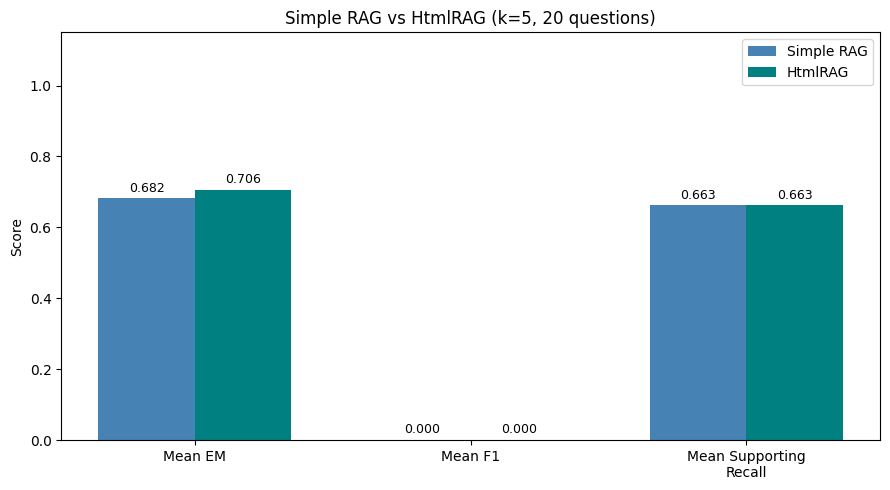

Saved: data/htmlrag_comparison.png


In [15]:
metrics  = ['Mean EM', 'Mean F1', 'Mean Supporting\nRecall']
simple_v = [mean_em_simple, mean_f1_simple, mean_spr_simple]
html_v   = [mean_em_html,   mean_f1_html,   mean_spr_html]

x   = range(len(metrics))
w   = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - w/2 for i in x], simple_v, w, label='Simple RAG', color='steelblue')
bars2 = ax.bar([i + w/2 for i in x], html_v,   w, label='HtmlRAG',    color='teal')

# Value labels on bars
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Simple RAG vs HtmlRAG (k=5, 20 questions)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'htmlrag_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Saved: data/htmlrag_comparison.png')


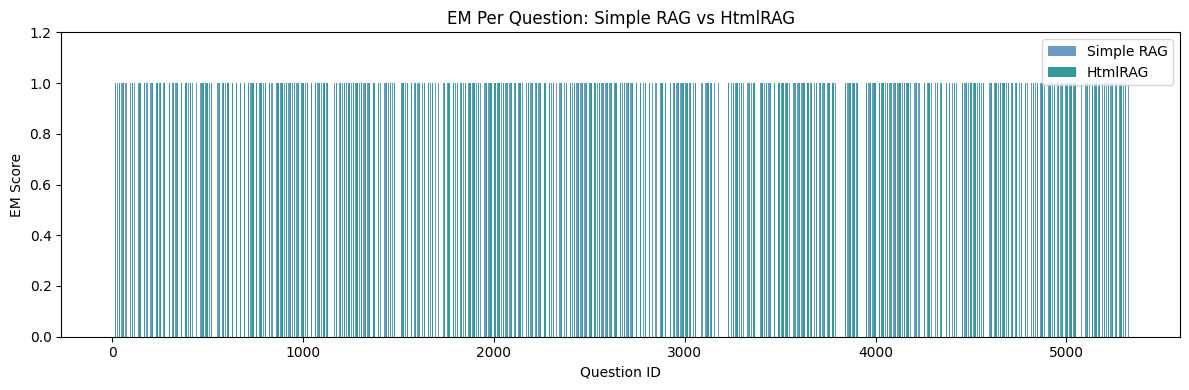

In [16]:
# Per-question EM: Simple RAG vs HtmlRAG
simple_em = [r['em'] for r in simple_data['per_question']]
html_em   = [r['em'] for r in results_html]
ids       = [r['id'] for r in results_html]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar([i - 0.2 for i in ids], simple_em, 0.35, label='Simple RAG', color='steelblue', alpha=0.8)
ax.bar([i + 0.2 for i in ids], html_em,   0.35, label='HtmlRAG',    color='teal',      alpha=0.8)
ax.set_xlabel('Question ID')
ax.set_ylabel('EM Score')
ax.set_title('EM Per Question: Simple RAG vs HtmlRAG')
ax.set_ylim(0, 1.2)
ax.legend()
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'htmlrag_per_question_em.png'), dpi=100, bbox_inches='tight')
plt.show()


In [17]:
with open(DATA_DIR / 'results_htmlrag.json', 'w') as f:
    json.dump({'mean_em': mean_em_html, 'mean_f1': mean_f1_html, 'mean_sr': mean_spr_html,
               'per_question': results_html}, f, indent=2)
print('Results saved → data/results_htmlrag.json')
print()
print('Open notebook 04_hyperrag.ipynb next.')


Results saved → data/results_htmlrag.json

Open notebook 04_hyperrag.ipynb next.
